# HF TDOA Analysis - Figure 12

This notebook uses the `hf_tdoa` library to analyze HF TDOA measurements for AB5YO on 40m and 60m bands.

In [1]:
import os
import datetime
import hf_tdoa as tdoa

%matplotlib inline

# Setup plotting style
tdoa.setup_plotting_style()

## Load WAV Files & Find Chirps for AB5YO 40m

In [2]:
# Path to chirp template - used for finding chirp locations via cross-correlation
# Use same template for all datasets.
template = os.path.join('../data/templates', 'N6RFM_10Hz_per_ms_template.wav')

In [3]:
# Path to data
base_dir   = '../data'
data_set_40m = 'TX_WA5FRF_EL09nn-RX_AB5YO_EL09mn-40m'
sweep_rate = 10  # Hz/ms

data_dir_40m = os.path.join(base_dir, data_set_40m)
wavlist_40m  = tdoa.obtain_wav_list(data_dir_40m)

In [4]:
# Correlate each WAV with a known template chirp to identify chirp locations in each WAV file.
chirps_40m = tdoa.find_chirps(wavlist_40m, template, sweep_rate=sweep_rate, plot_correlation=False)


Finding Chirps via Cross-Correlation
  Path Info:      PathInfo(TX: WA5FRF (EL09nn), RX: AB5YO (EL09mn), Range: 8.1 km, Band: 7 MHz)
  Template:       N6RFM_10Hz_per_ms_template.wav
  Sweep Rate:     10 Hz/ms
  Files to Process: 49
  Chirps per File: Top 10



Finding chirps: 100%|██████████| 49/49 [00:02<00:00, 20.43file/s, Chirps=10, Max Corr=5.40e+02]

✓ Completed chirp detection: 49 files processed, 490 total chirps found



## Find TDOAs for AB5YO 40m

In [5]:
debug_TDOAs = False

# Process the 2F2-1F2 mode for 40m
chirps_40m = tdoa.find_TDOAs(chirps_40m, mode_string='2F2-1F2',
                             plot_fft=debug_TDOAs, only_one=debug_TDOAs)

# Build the TDOA configuration dictionary
tdoa_dct_40m = tdoa.build_tdoa_config(chirps_40m, mode_strings=['2F2-1F2'])


Processing Mode: 2F2-1F2
  Filter Limits:  10.0 - 50.0 Hz
  Search Window:  -0.10 to 0.10 s offset
  Freq Range:     11.0 - 20.0 Hz
  Set Name:       2F2-1F2
  Sweep Rate:     10 Hz/ms
  Files to Process: 49



Finding TDOAs (2F2-1F2): 100%|██████████| 49/49 [00:09<00:00,  5.09file/s, Mean TDOA=1.87 ms]


✓ Completed processing 2F2-1F2: 49 files processed


Path Information
  PathInfo(TX: WA5FRF (EL09nn), RX: AB5YO (EL09mn), Range: 8.1 km, Band: 7 MHz)

TX Location: 29.563°N, -98.875°E (EL09nn)
RX Location: 29.563°N, -98.958°E (EL09mn)

Path Midpoint: 29.563°N, -98.917°E

Path Azimuth (TX→RX): -90.0°

Calculated TDOA Model Coefficients:
2F2-1F2      (2F2-1F2 ): slope= 150.0, intercept=   0.0



## Load WAV Files & Find Chirps for AB5YO 60m

In [6]:
data_set_60m = 'TX_WA5FRF_EL09nn-RX_AB5YO_EL09mn-60m'

data_dir_60m = os.path.join(base_dir, data_set_60m)
wavlist_60m  = tdoa.obtain_wav_list(data_dir_60m)

In [7]:
# Correlate each WAV with the 60m template chirp
chirps_60m = tdoa.find_chirps(wavlist_60m, template, sweep_rate=sweep_rate, plot_correlation=False)


Finding Chirps via Cross-Correlation
  Path Info:      PathInfo(TX: WA5FRF (EL09nn), RX: AB5YO (EL09mn), Range: 8.1 km, Band: 5 MHz)
  Template:       N6RFM_10Hz_per_ms_template.wav
  Sweep Rate:     10 Hz/ms
  Files to Process: 39
  Chirps per File: Top 10



Finding chirps: 100%|██████████| 39/39 [00:01<00:00, 20.42file/s, Chirps=10, Max Corr=5.20e+02]

✓ Completed chirp detection: 39 files processed, 390 total chirps found



## Find TDOAs for AB5YO 60m

In [8]:
# Process the 2F2-1F2 mode for 60m
chirps_60m = tdoa.find_TDOAs(chirps_60m, mode_string='2F2-1F2',
                             plot_fft=debug_TDOAs, only_one=debug_TDOAs)

# Build the TDOA configuration dictionary
tdoa_dct_60m = tdoa.build_tdoa_config(chirps_60m, mode_strings=['2F2-1F2'])


Processing Mode: 2F2-1F2
  Filter Limits:  10.0 - 50.0 Hz
  Search Window:  -0.10 to 0.10 s offset
  Freq Range:     11.0 - 20.0 Hz
  Set Name:       2F2-1F2
  Sweep Rate:     10 Hz/ms
  Files to Process: 39



Finding TDOAs (2F2-1F2): 100%|██████████| 39/39 [00:07<00:00,  5.08file/s, Mean TDOA=1.66 ms]


✓ Completed processing 2F2-1F2: 39 files processed


Path Information
  PathInfo(TX: WA5FRF (EL09nn), RX: AB5YO (EL09mn), Range: 8.1 km, Band: 5 MHz)

TX Location: 29.563°N, -98.875°E (EL09nn)
RX Location: 29.563°N, -98.958°E (EL09mn)

Path Midpoint: 29.563°N, -98.917°E

Path Azimuth (TX→RX): -90.0°

Calculated TDOA Model Coefficients:
2F2-1F2      (2F2-1F2 ): slope= 150.0, intercept=   0.0



## Create Figure 12: AB5YO 40m and 60m Subplots

Figure 12 shows layer height measurements from AB5YO on both 40m (top panel) and 60m (bottom panel) bands.

Figure saved to: fig_12.jpg


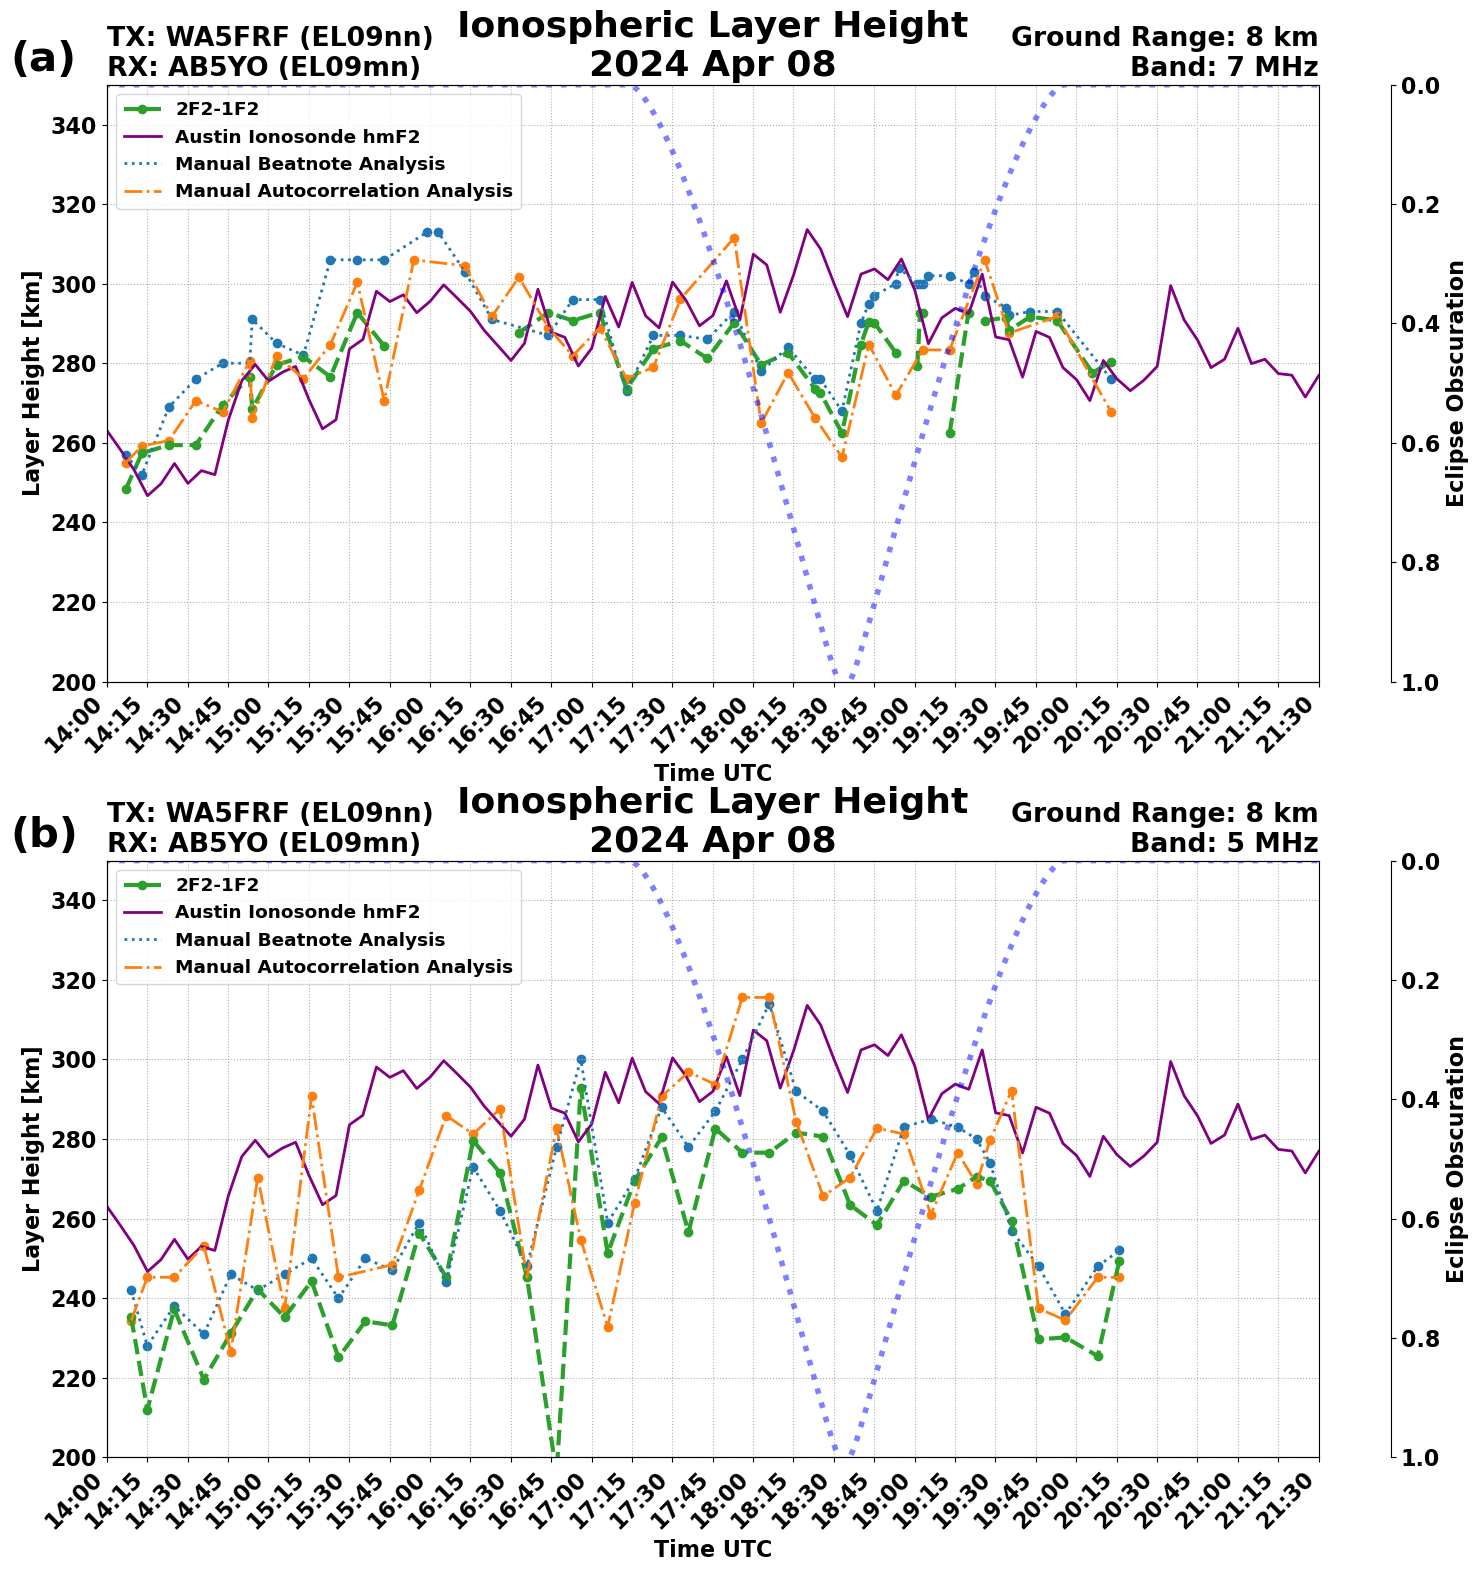

In [9]:
# Get path_info for solar calculations - use AB5YO location
path_info_40m = chirps_40m.attrs['path_info']
solar_lat, solar_lon = path_info_40m.get_midpoint()

# Set time limits for consistent x-axis across subplots
xlim = (datetime.datetime(2024, 4, 8, 14, 0), datetime.datetime(2024, 4, 8, 21, 30))

# Create the subplot figure with both 40m and 60m
# Compare two verified manual analysis methods for each band:
# - Manual Beatnote Analysis (blue dotted)
# - Manual Autocorrelation Analysis (orange dashed)
tdoa.plot_hmf2_subplot(
    chirps_list=[chirps_40m, chirps_60m],
    tdoa_dct_list=[tdoa_dct_40m, tdoa_dct_60m],
    subplot_labels=['(a)', '(b)'],
    ylim=(200, 350),
    xlim=xlim,
    solar_lat=solar_lat,
    solar_lon=solar_lon,
    overlay_eclipse=True,
    ionosonde_dct={'overlay_hmE': False},
    tdoa_csv_dct_list=[
        {
            'csv_path_beatnote': '../data/CSVs/2024-04-08_TX_WA5FRF_EL09nn-RX_AB5YO_EL09mn-40m_manual_beatnote_analysis.csv',
            'csv_path_autocorr': '../data/CSVs/2024-04-08_TX_WA5FRF_EL09nn-RX_AB5YO_EL09mn-40m_manual_autocorrelation_analysis.csv'
        },
        {
            'csv_path_beatnote': '../data/CSVs/2024-04-08_TX_WA5FRF_EL09nn-RX_AB5YO_EL09mn-60m_manual_beatnote_analysis.csv',
            'csv_path_autocorr': '../data/CSVs/2024-04-08_TX_WA5FRF_EL09nn-RX_AB5YO_EL09mn-60m_manual_autocorrelation_analysis.csv'
        }
    ],
    figsize=(15, 16),
    legend_loc='upper left',
    legend_fontsize='small',
    savefig='fig_12.jpg'
)